# Изучение регуляризации в scikit-learn

- как реализовать L2-регуляризацию (Ridge) с помощью библиотеки sklearn и как она влияет на поведение модели;
- как реализовать L1-регуляризацию (Lasso) с помощью библиотеки sklearn и почему она может автоматически обнулять неинформативные признаки;
- как подбирать значение коэффициента регуляризации ( alpha, λ) и как он влияет на веса и метрики;
- как регуляризация помогает справляться с шумом в данных и переобучением.


## Подготовка данных


Будем работать с готовым датасетом, который импортируем из CSV. В нём:

- 200 наблюдений;
- 40 признаков — среди них 10 информативных, реально влияющих на целевую переменную y;
- 30 шумовых признаков, не влияющих на y;
- добавлен сильный шум и корреляция некоторых признаков.

После импорта данные делятся на train, validation и test:

- Тестовая выборка (20%) отделяется первой.
- Из оставшихся данных 20% выделяется под валидационную выборку.
- Остаток используется для обучения.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Загружаем данные из CSV
df = pd.read_csv("../data/synthetic_regression.csv")

# Разделяем на X и y
X = df.drop(columns="target").values
y = df["target"].values

# Сначала отделяем тестовую выборку (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Из оставшихся 80% берём 20% для валидации
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42
)

# Вывод размеров
print(f"Train size: {X_train.shape[0]}, Val size: {X_val.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Train shape:     X = {X_train.shape}, y = {y_train.shape}")
print(f"Validation shape: X = {X_val.shape}, y = {y_val.shape}")
print(f"Test shape:      X = {X_test.shape}, y = {y_test.shape}")

Train size: 128, Val size: 32, Test size: 40
Train shape:     X = (128, 40), y = (128,)
Validation shape: X = (32, 40), y = (32,)
Test shape:      X = (40, 40), y = (40,)


### Разбиение данных на Train, Validation и Test

Для корректного обучения и оценки модели данные были разделены на три части:

- Train (обучающая выборка) — на этих данных модель «учится», подбирая коэффициенты, чтобы минимизировать ошибку предсказаний.
- Validation (валидационная выборка) — используется для подбора гиперпараметров и выбора наилучшей конфигурации модели. Позволяет оценить, как изменения настроек модели влияют на качество предсказаний, не используя данные из тестовой выборки.
- Test (тестовая выборка) — независимая проверка модели. Показывает, насколько выбранная наилучшая модель способна обобщать знания на новых, неизвестных данных, и оценивает её реальную производительность.

### Истинные коэффициенты для оценки модели


Также импортируем вектор истинных коэффициентов true_coefs, который показывает, какие признаки реально влияют на целевую переменную. С его помощью можно сравнить результаты модели с истиной и оценить, насколько эффективно работает регуляризация.

In [3]:
# Импортируем истинные коэффициенты
true_coefs_df = pd.read_csv("../data/true_coefs.csv")
true_coefs = true_coefs_df["coef"].values

print("Форма true_coefs:", true_coefs.shape)
# Выводим истинные коэффициенты
print("Истинные коэффициенты (true_coefs):")
print(true_coefs)

Форма true_coefs: (40,)
Истинные коэффициенты (true_coefs):
[ 0.          0.          0.          0.          0.         92.46228178
  0.         39.13780934  0.         62.49224698  0.          0.
  0.          0.          0.         78.39252791  0.          3.18567625
  0.          0.          0.          0.          0.          0.
  0.          0.         39.75918693 51.92800824  0.         77.98186756
  0.          0.          0.         46.93029964  0.          0.
  0.          0.          0.         85.79519454]


### Распределение целевой переменной в выборках

Чтобы убедиться, что данные были правильно распределены между выборками, построим гистограмму для распределения целевой переменной y в каждой из них.

Посмотрим на распределения целевой переменной в разных выборках. Гистограмма показывает, как часто встречаются разные значения целевой переменной y в каждой выборке.
- По оси X — значения y.
- По оси Y — частота встречаемости этих значений.
- Разные цвета — разные выборки: Train, Validation, Test.

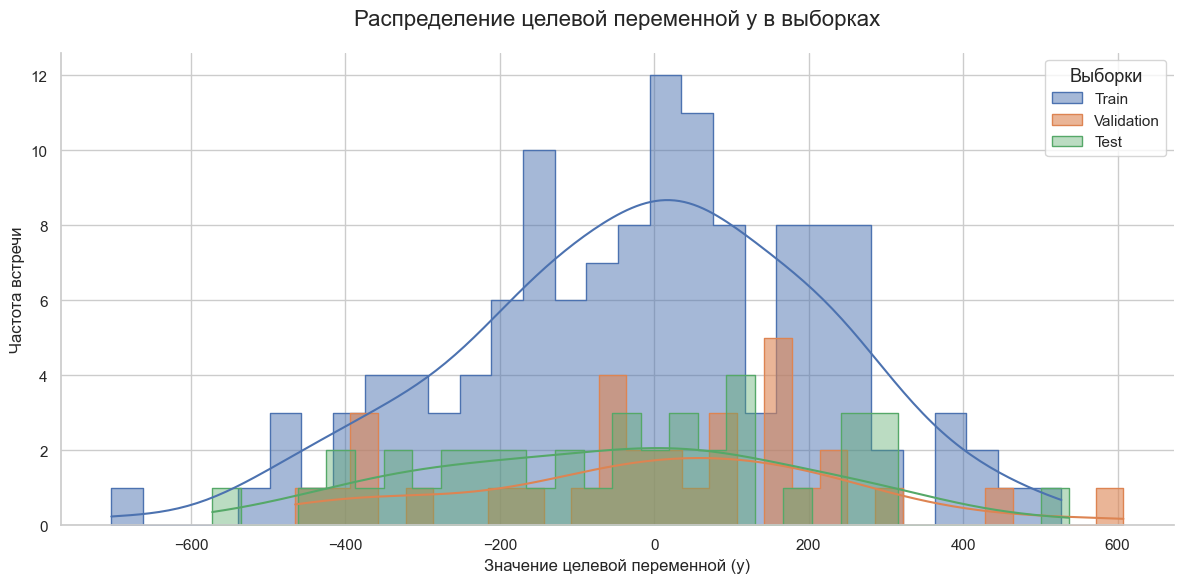

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Устанавливаем премиальный стиль отображения
sns.set_theme(style="whitegrid", palette="muted")
plt.figure(figsize=(12, 6))

# Строим гистограммы для каждой выборки
# kde=True добавляет линию оценки плотности распределения
sns.histplot(y_train, label='Train', color='#4C72B0', alpha=0.5, kde=True, element="step", bins=30)
sns.histplot(y_val, label='Validation', color='#DD8452', alpha=0.6, kde=True, element="step", bins=30)
sns.histplot(y_test, label='Test', color='#55A868', alpha=0.4, kde=True, element="step", bins=30)

# Настройка осей и заголовка
plt.title('Распределение целевой переменной y в выборках', fontsize=16, pad=20)
plt.xlabel('Значение целевой переменной (y)', fontsize=12)
plt.ylabel('Частота встречи', fontsize=12)

# Добавляем легенду
plt.legend(title="Выборки", title_fontsize='13', fontsize='11')

# Убираем лишние границы для чистоты дизайна
sns.despine()

plt.tight_layout()
plt.show()


Несмотря на разный размер выборок, распределения целевой переменной в Train, Validation и Test схожи по форме, хотя их плотность немного различается. Это говорит о корректном разбиении данных, где каждая выборка отражает общее распределение.

Если бы распределения сильно различались, модель хуже обобщала бы знания. Например, в тестовой выборке могли бы появиться значения, которых не было в обучающей.

## Модель без регуляризации


Прежде чем использовать регуляризацию, создадим базовую модель — линейную регрессию без штрафов. 
Это позволит:
- понять, как модель ведёт себя без ограничений;
- сравнить её поведение и качество с регуляризованными версиями;
- увидеть, как сильно шумовые признаки могут влиять на веса.

Для обучения базовой модели используется только обучающая выборка. Поскольку у линейной регрессии без регуляризации нет гиперпараметров (например, alpha ), отдельный этап подбора параметров через валидационную выборку не проводится.
Однако валидационная выборка всё равно используется для оценки качества модели (в коде ниже предсказания делаются именно на X_val ).

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Обучаем LinearRegression на обучающей выборке
lr = LinearRegression()

lr.fit(X_train, y_train)

# Предсказываем на валидационной выборке
y_pred_lr = lr.predict(X_val)

# Оцениваем качество
mse_lr = mean_squared_error(y_val, y_pred_lr)
r2_lr = r2_score(y_val, y_pred_lr)

print(f"\nLinearRegression → MSE: {mse_lr:.3f}, R2: {r2_lr:.3f}")


LinearRegression → MSE: 20064.504, R2: 0.672


Разберём, что получилось:

- MSE (Mean Squared Error) — среднеквадратичная ошибка. Значение 20064.504 говорит о том, что предсказания модели в среднем сильно отклоняются от настоящих значений y. Высокое значение MSE обусловлено шумностью данных и большим числом признаков, часть из которых неинформативна.
- R² (коэффициент детерминации) — показывает, какую долю дисперсии целевой переменной объясняет модель. Значение 0.672 означает, что модель объясняет около 67.2% изменчивости данных, а оставшиеся ~32.8% — это необъяснённая вариация (ошибка, шум, неучтённые факторы).

Чтобы сравнить, как линейная регрессия без регуляризации распределяет веса и как они соотносятся с истинными коэффициентами, построим один график с двумя наборами столбцов:

- истинные коэффициенты ( true_coefs ) — те, что были заданы при генерации данных;
- коэффициенты модели LinearRegression — обученной на данных без регуляризации.

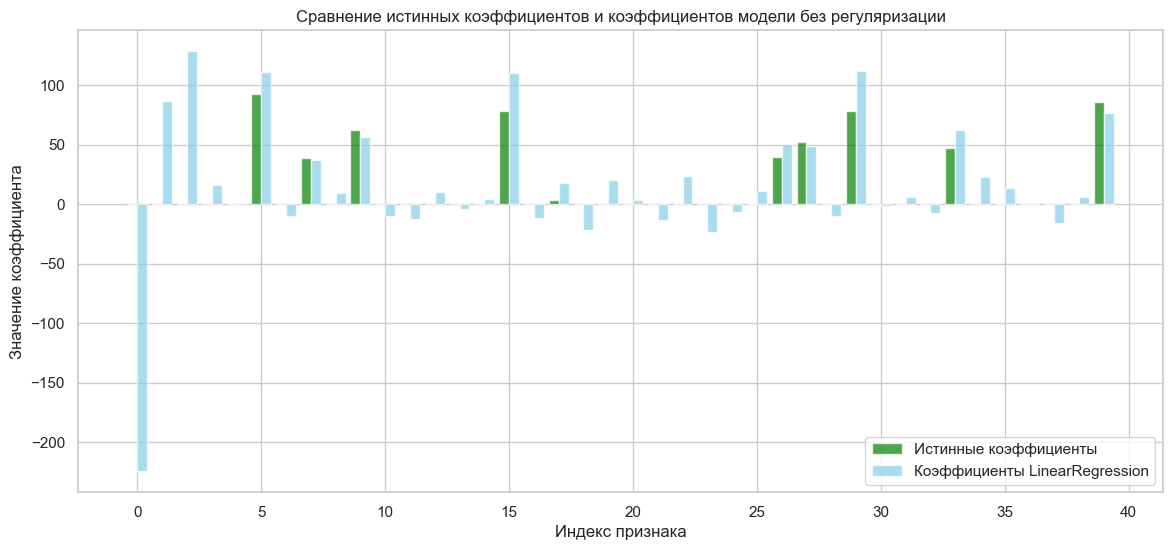

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Создаём массив индексов признаков для оси X
indices = np.arange(len(true_coefs))

plt.figure(figsize=(14, 6))  # Размер графика
width = 0.4  # Ширина столбцов на графике

# Строим столбцы для истинных коэффициентов, смещаем их влево для визуального разделения
plt.bar(indices - width/2, true_coefs, width=width, label='Истинные коэффициенты', color='green', alpha=0.7)

# Строим столбцы для коэффициентов, полученных моделью LinearRegression, смещаем вправо
plt.bar(indices + width/2, lr.coef_, width=width, label='Коэффициенты LinearRegression', color='skyblue', alpha=0.7)

plt.xlabel('Индекс признака')  # Подпись оси X
plt.ylabel('Значение коэффициента')  # Подпись оси Y
plt.title('Сравнение истинных коэффициентов и коэффициентов модели без регуляризации')  # Заголовок графика
plt.legend()  # Отображаем легенду
plt.show()  # Показываем график

Разберём, о чём говорит график:
 - У истинных коэффициентов много нулевых значений — это шумовые признаки. Ненулевые коэффициенты соответствуют важным признакам.
 - Коэффициенты линейной регрессии часто имеют ненулевые значения даже там, где истинные коэффициенты равны нулю, — модель пытается подстроиться под шум.
 - Такое поведение ведёт к переобучению и снижению качества на валидационной выборке.